# **Game 1 Data Clustering**

In [44]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Data Load

In [45]:
import os
import json
#load data from data folder of json files

json_folder_path = '/content/drive/MyDrive/data'

data = []

# Check if the folder exists
if not os.path.exists(json_folder_path):
    print(f"Error: Folder '{json_folder_path}' not found. Please create it and place your JSON files inside, or update the 'json_folder_path' variable.")
else:
    # Iterate over each file in the directory
    for filename in os.listdir(json_folder_path):
        if filename.endswith('.json'):
            file_path = os.path.join(json_folder_path, filename)
            try:
                with open(file_path, 'r') as f:
                    json_data = json.load(f)
                    # Assuming each JSON file contains a list of records or a single record to be appended
                    if isinstance(json_data, list):
                        data.extend(json_data)
                    else:
                        data.append(json_data)
            except json.JSONDecodeError as e:
                print(f"Error decoding JSON from {filename}: {e}")
            except Exception as e:
                print(f"Error reading {filename}: {e}")

print(f"Loaded {len(data)} records from JSON files in '{json_folder_path}'.")

Loaded 116 records from JSON files in '/content/drive/MyDrive/data'.


## Import Libraries

In [46]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA



## Data Cleaning And Feature Selection

In [47]:
df = pd.DataFrame(data)

# print("Raw Data:\n", df.head())

#cleaning data
df = df[
    (df["moves"] > 0) &
    (df["optimal_moves"].notna())
]


In [48]:
df.head()

,moves,optimal_moves,excess_moves,avg_latency,path_consistency,repeat_error_rate,success,level,run,first_input_time,fail_count
0,6,6.0,0.0,406.800000,1.0,0,True,0,0,1249.0,0
1,7,7.0,0.0,289.000000,1.0,0,True,1,1,4258.0,0
2,10,10.0,0.0,530.222222,0.7,0,True,2,2,6796.0,0
3,6,6.0,0.0,317.400000,1.0,0,True,0,0,14884.0,0
4,7,7.0,0.0,338.333333,1.0,0,True,1,1,17393.0,0


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 58 entries, 0 to 115
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   moves              58 non-null     int64  
 1   optimal_moves      58 non-null     float64
 2   excess_moves       58 non-null     float64
 3   avg_latency        58 non-null     float64
 4   path_consistency   58 non-null     float64
 5   repeat_error_rate  58 non-null     int64  
 6   success            58 non-null     bool   
 7   level              58 non-null     int64  
 8   run                58 non-null     int64  
 9   first_input_time   58 non-null     float64
 10  fail_count         58 non-null     int64  
dtypes: bool(1), float64(5), int64(5)
memory usage: 5.0 KB


In [50]:
#remove error_rate and fail_count
df.drop(columns=["repeat_error_rate"], inplace=True)
df.drop(columns= ["fail_count"], inplace=True)


In [51]:
df.head()

,moves,optimal_moves,excess_moves,avg_latency,path_consistency,success,level,run,first_input_time
0,6,6.0,0.0,406.800000,1.0,True,0,0,1249.0
1,7,7.0,0.0,289.000000,1.0,True,1,1,4258.0
2,10,10.0,0.0,530.222222,0.7,True,2,2,6796.0
3,6,6.0,0.0,317.400000,1.0,True,0,0,14884.0
4,7,7.0,0.0,338.333333,1.0,True,1,1,17393.0


In [52]:
df.tail()

,moves,optimal_moves,excess_moves,avg_latency,path_consistency,success,level,run,first_input_time
104,7,7.0,0.0,340.166667,1.000,True,1,2,13570.0
106,10,10.0,7.0,430.444444,0.700,True,2,4,19072.0
107,6,6.0,0.0,270.200000,1.000,True,0,0,1112.0
111,7,7.0,0.0,324.666667,1.000,True,1,4,6580.0
115,16,10.0,6.0,330.200000,0.625,True,2,10,14379.0


## Standardization

In [53]:
#standardization
from sklearn.preprocessing import StandardScaler
gamedata= StandardScaler().fit_transform(df)

In [54]:
gamedata

array([[-7.09746204e-01, -9.96953070e-01, -6.25559033e-01,
        -2.39539139e-01,  7.95110930e-01,  2.72165527e-01,
        -1.24079984e+00, -7.77188926e-01, -3.85862288e-01],
       [-4.93086836e-01, -4.12879554e-01, -6.25559033e-01,
        -4.89767021e-01,  7.95110930e-01,  2.72165527e-01,
        -2.10305058e-02, -5.34839691e-01, -3.42966060e-01],
       [ 1.56891266e-01,  1.33934099e+00, -6.25559033e-01,
         2.26313296e-02, -1.08753711e+00,  2.72165527e-01,
         1.19873883e+00, -2.92490456e-01, -3.06784396e-01],
       [-7.09746204e-01, -9.96953070e-01, -6.25559033e-01,
        -4.29440435e-01,  7.95110930e-01,  2.72165527e-01,
        -1.24079984e+00, -7.77188926e-01, -1.91482073e-01],
       [-4.93086836e-01, -4.12879554e-01, -6.25559033e-01,
        -3.84974360e-01,  7.95110930e-01,  2.72165527e-01,
        -2.10305058e-02, -5.34839691e-01, -1.55713833e-01],
       [ 1.67350684e+00,  1.33934099e+00,  4.23932568e-01,
         8.57517966e-02, -3.12329092e-01,  2.721655

## Clustering using DBSCAN

In [55]:
db_scan= DBSCAN(eps=0.5, min_samples=3)


[ 0  1  2  0  1  3  0  1  3 -1 -1 -1 -1  1 -1 -1  1  3 -1 -1 -1  0  1  2
 -1 -1 -1  0  1  2 -1 -1 -1 -1  1  2 -1  1  2 -1 -1 -1 -1 -1 -1 -1  0 -1
 -1 -1 -1 -1 -1  1 -1  0  1 -1]
Clusters: 4
Noise points: 32


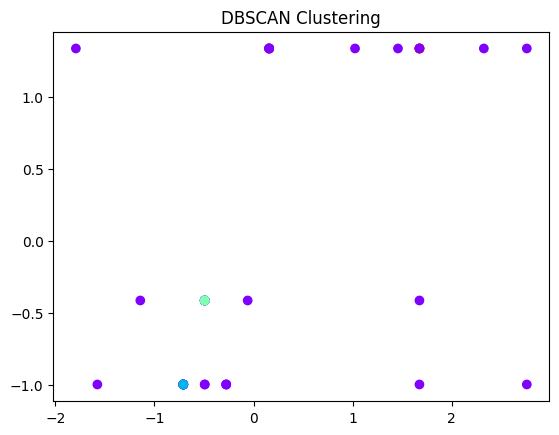

In [56]:
db_scan= DBSCAN(eps=0.6, min_samples=3)
label=db_scan.fit_predict(gamedata)



print(label)  # cluster labels (-1 = noise)

import numpy as np

n_clusters = len(set(label)) - (1 if -1 in label else 0)
n_noise = list(label).count(-1)

print("Clusters:", n_clusters)
print("Noise points:", n_noise)

# Plot
plt.scatter(gamedata[:, 0], gamedata[:, 1], c=label, cmap='rainbow')
plt.title("DBSCAN Clustering")
plt.show()


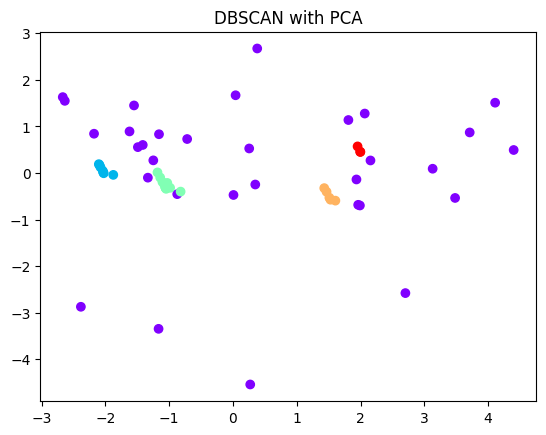

In [57]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(gamedata)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=label, cmap='rainbow')
plt.title("DBSCAN with PCA")
plt.show()

## Result 1

In [58]:
df['cluster'] = label

In [59]:
cluster_summary = df.groupby('cluster').mean()
print(cluster_summary)

           moves  optimal_moves  excess_moves  avg_latency  path_consistency  \
cluster                                                                        
-1        9.9375           7.75       6.90625   627.974992          0.833774   
 0        6.0000           6.00       0.00000   356.628571          1.000000   
 1        7.0000           7.00       0.00000   402.166667          1.000000   
 2       10.0000          10.00       0.00000   346.577778          0.700000   
 3       17.0000          10.00       7.00000   462.208333          0.823529   

         success  level       run  first_input_time  
cluster                                              
-1         0.875    1.0  4.718750      43814.000000  
 0         1.000    0.0  0.285714       4629.428571  
 1         1.000    1.0  1.454545      10208.818182  
 2         1.000    2.0  2.200000       9858.400000  
 3         1.000    2.0  2.000000      15422.666667  


## Classification using Random Forest

In [60]:
# from sklearn.ensemble import RandomForestClassifier

# X_df = df2.drop(columns=['cluster'])
# y_df = df2['cluster']

# model = RandomForestClassifier()
# model.fit(X_df, y_df)

## Prediction

In [61]:
# new_player = [[10, 9, 1, 450, 0.85, 1, 1, 1, 12000]]
# pred = model.predict(new_player)

# pred

# Load Synthetic Data

In [62]:
df2=pd.read_csv("/content/drive/MyDrive/Red Block Grid/generated_players_data.csv")

In [63]:
df2.head()

,player_id,category,moves,optimal_moves,excess_moves,avg_latency,path_consistency,repeat_error_rate,success,level,run,first_input_time,fail_count
0,P_1000,average,7,6.0,1.0,352.44,0.78,0,True,0,0,14411,0
1,P_1000,average,7,7.0,0.0,571.79,0.73,0,True,1,1,19369,0
2,P_1000,average,11,10.0,1.0,395.07,0.77,0,True,2,2,26473,0
3,P_1001,average,4,NaN,NaN,945.97,0.83,0,False,0,0,10893,1
4,P_1001,average,6,6.0,0.0,373.36,0.93,0,True,0,1,18323,0


## Cleaning and Feature Selection

In [64]:
#cleaning data
df2 = df2[
    (df2["moves"] > 0) &
    (df2["optimal_moves"].notna())
]

In [65]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 300 entries, 0 to 381
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   player_id          300 non-null    object 
 1   category           300 non-null    object 
 2   moves              300 non-null    int64  
 3   optimal_moves      300 non-null    float64
 4   excess_moves       300 non-null    float64
 5   avg_latency        300 non-null    float64
 6   path_consistency   300 non-null    float64
 7   repeat_error_rate  300 non-null    int64  
 8   success            300 non-null    bool   
 9   level              300 non-null    int64  
 10  run                300 non-null    int64  
 11  first_input_time   300 non-null    int64  
 12  fail_count         300 non-null    int64  
dtypes: bool(1), float64(4), int64(6), object(2)
memory usage: 30.8+ KB


In [66]:
#remove
df2.drop(columns=["repeat_error_rate"], inplace=True)
df2.drop(columns= ["fail_count"], inplace=True)
df2.drop(columns= ["category"], inplace=True)
df2.drop(columns= ["player_id"], inplace=True)


In [67]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 300 entries, 0 to 381
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   moves             300 non-null    int64  
 1   optimal_moves     300 non-null    float64
 2   excess_moves      300 non-null    float64
 3   avg_latency       300 non-null    float64
 4   path_consistency  300 non-null    float64
 5   success           300 non-null    bool   
 6   level             300 non-null    int64  
 7   run               300 non-null    int64  
 8   first_input_time  300 non-null    int64  
dtypes: bool(1), float64(4), int64(4)
memory usage: 21.4 KB


## Standardization

In [68]:
#standardization
from sklearn.preprocessing import StandardScaler
data_std= StandardScaler().fit_transform(df2)

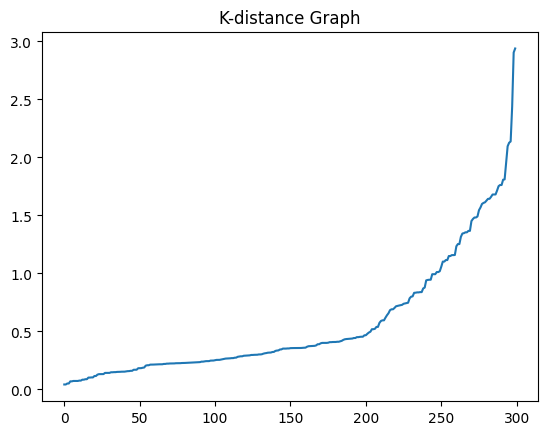

In [69]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(data_std)
distances, indices = neighbors_fit.kneighbors(data_std)

distances = np.sort(distances[:, 1])
plt.plot(distances)
plt.title("K-distance Graph")
plt.show()

## Clustering Using DBSCAN

[ 0 -1  1 -1 -1 -1 -1 -1 -1 -1  2 -1  0  2  1  0  2 -1 -1 -1 -1  0  2  1
  0  2  1  0  2  1  0  2  1  0  2  1 -1 -1 -1  0  2  1 -1 -1 -1  0  2  1
  0 -1 -1 -1 -1 -1  0  2  1  0  2  1 -1 -1 -1  0  2  1  0  2  1 -1 -1 -1
 -1 -1 -1  0  2  1 -1 -1 -1  0  2  1  0  2  1 -1 -1 -1  0  2  1 -1 -1 -1
  0  2 -1  0  2  1  0 -1  1 -1 -1 -1  0  2  1  0  2 -1  0  2  1 -1 -1 -1
  0  2  1  0  2  1  0  2  1 -1 -1 -1  0  2  1  0  2  1  0 -1 -1  0  2  1
  0  2  1 -1 -1 -1  0  2  1  0  2  1  0  2  1 -1 -1 -1  0 -1 -1 -1 -1 -1
 -1  2  1  0  2  1  0 -1 -1 -1 -1 -1  0  2  1  0  2  1  0 -1 -1  0  2  1
  0 -1 -1  0  2  1 -1 -1 -1  0  2  1  0  2  1  0 -1  1  0 -1 -1 -1 -1 -1
  0  2  1 -1  2  1  0  2 -1 -1 -1 -1 -1 -1 -1  0  2  1 -1 -1 -1  0  2  1
  0  2 -1  0  2  1  0  2  1  0  2  1  0  2  1  0  2  1  0  2  1  0  2  1
 -1 -1  1 -1 -1 -1  0  2 -1 -1 -1 -1  0  2  1  0  2  1  0  2  1  0  2  1
  0  2  1  0 -1 -1 -1 -1 -1 -1 -1 -1]
Clusters: 3
Noise points: 115


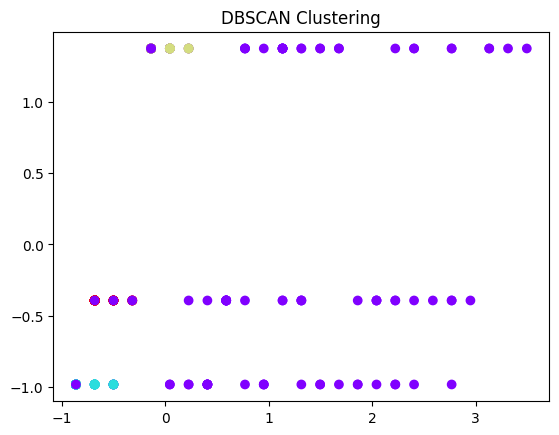

In [70]:
db_scan2= DBSCAN(eps=0.6, min_samples=5)
label2=db_scan2.fit_predict(data_std)



print(label2)  # cluster labels (-1 = noise)

import numpy as np

n_clusters = len(set(label2)) - (1 if -1 in label2 else 0)
n_noise = list(label2).count(-1)

print("Clusters:", n_clusters)
print("Noise points:", n_noise)

# Plot
plt.scatter(data_std[:, 0], data_std[:, 1], c=label2, cmap='rainbow')
plt.title("DBSCAN Clustering")
plt.show()


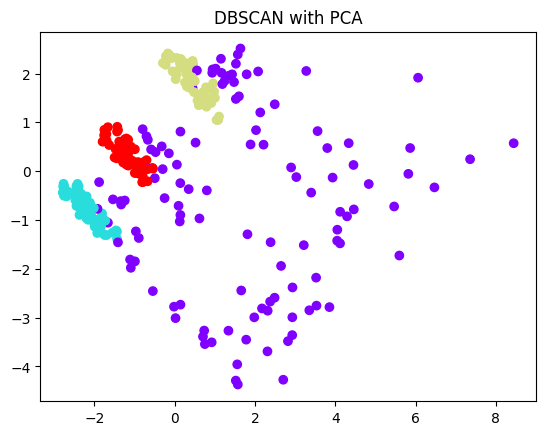

In [71]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(data_std)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=label2, cmap='rainbow')
plt.title("DBSCAN with PCA")
plt.show()

In [72]:
df2['cluster'] = label2

In [73]:
cluster_summary = df2.groupby('cluster').mean()
print(cluster_summary)

             moves  optimal_moves  excess_moves  avg_latency  \
cluster                                                        
-1       15.417391       7.843478      7.573913   664.307043   
 0        6.308824       6.000000      0.308824   402.917941   
 1       10.368421      10.000000      0.368421   433.676316   
 2        7.233333       7.000000      0.233333   404.538000   

         path_consistency  success     level       run  first_input_time  
cluster                                                                   
-1               0.702000      1.0  1.095652  2.469565      28310.217391  
 0               0.853382      1.0  0.000000  0.000000       8021.544118  
 1               0.860526      1.0  2.000000  2.000000      21251.561404  
 2               0.868833      1.0  1.000000  1.000000      14560.183333  


##Results 2

```
# This is formatted as code
```



### 🟣 Cluster -1 (Noise — 115 players)
* Moves: 15.4 (VERY high)
* Excess moves: 7.57 (VERY inefficient)
* Latency: 664 (VERY slow)
* Path consistency: 0.70 (LOW)
* First input time: very high

**Slow + inefficient + inconsistent**
- Label
“Low Cognitive Performance / Struggling Players”

### 🔴Cluster 0

* Moves ≈ optimal (6.3 vs 6)
* Very low excess moves
* Low latency (~402)
* Good consistency (0.85)
* Very low first input time

**Fast + efficient + consistent**

- Label:
“High Cognitive Efficiency (Fast & Accurate)”

### 🟡 Cluster 1
* Moves ≈ optimal (10.36 vs 10)
* Low excess moves
* Slightly higher latency (~433)
* High consistency (0.86)
* Higher first input time

**Slower but still accurate and consistent**

- Label:
“Deliberate Thinkers (Slow but Accurate)”

### 🔵 Cluster 2

* Moves ≈ optimal (7.23 vs 7)
* Lowest excess moves (best efficiency)
* Low latency (~404)
* Highest consistency (0.868)

**Very balanced: fast + accurate + highly consistent**

- Label:
“Optimal Performers (Balanced Cognitive Ability)

## Classification Using Random Forest

In [74]:
from sklearn.ensemble import RandomForestClassifier

X = df2.drop(columns=['cluster'])
y = df2['cluster']

model = RandomForestClassifier()
model.fit(X, y)

RandomForestClassifier()

## Prediction

In [75]:
new_player = [[10, 9, 1, 450, 0.85, 1, 1, 1, 12000]]
pred = model.predict(new_player)



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [76]:
pred

array([1])